# Testing LinBin flow for DEIMOS data

Set imports and paths

In [1]:
from eregion.tasks import ImageCreator, AssembleFocalPlane
from eregion.tasks.custom import guess_image_type_from_filename_DEIMOS, load_image_fits_DEIMOS
from eregion.tasks.calibration import MasterBias, CalibrationResult, MasterCombine
from eregion.tasks.preprocessing import BiasSubtraction, ScanSubtraction, SigmaClipMasking
from eregion.tasks.linbin import LinBin, LinBinResult

import numpy as np
import os
import glob2
import importlib
import matplotlib.pyplot as plt
from functools import partial

In [2]:
basepath = '/Users/yashvi/Desktop/Detector Characterization Tools/DTU_dettest/DTU_fullfp_bringup/bintest/SCI/'
inp = os.path.join(basepath, '20260722-171930')
out = inp.replace('DTU_dettest', 'DTU_detreduce')
os.makedirs(out, exist_ok=True)

Load images. Looking at image type table for the loaded data, images relevant for this notebook are bias, linbin, and flat, so we filter and keep only those.

In [3]:
imtask = ImageCreator(detector_config='../src/eregion/configs/detectors/deimos_sci.yaml')
imres = imtask.run(input_source=inp, identifier_func=guess_image_type_from_filename_DEIMOS, fileloader_func=load_image_fits_DEIMOS, data_on_demand=True)
bundle = imres.data('type == "bias" | type =="linbin" | type == "flat"')
del imres
bundle

2026-09-04 18:54:20,214 - DetectorConfig - INFO - Config loaded from file '../src/eregion/configs/detectors/deimos_sci.yaml'
2026-09-04 18:54:20,214 - image_creator - INFO - Item /Users/yashvi/Desktop/Detector Characterization Tools/DTU_dettest/DTU_fullfp_bringup/bintest/SCI/20260722-171930 is a regular path string
2026-09-04 18:54:20,220 - eregion.utils.io_utils - INFO - Found 240 FITS files in directory /Users/yashvi/Desktop/Detector Characterization Tools/DTU_dettest/DTU_fullfp_bringup/bintest/SCI/20260722-171930 and its sub-directories.


,type,exptime,obstime,seqnum,led,backbias,det_id,filename,object,extra_0
0,bias,0.00,2026-07-22T171946.612,0,GREEN,-60.0,det_1,/Users/yashvi/Desktop/Detector Characterizatio...,<eregion.datamodels.image.DetImage object at 0...,NaN
1,bias,0.00,2026-07-22T172111.610,1,GREEN,-60.0,det_1,/Users/yashvi/Desktop/Detector Characterizatio...,<eregion.datamodels.image.DetImage object at 0...,NaN
2,flat,0.06,2026-07-22T172817.773,0,GREEN,-60.0,det_1,/Users/yashvi/Desktop/Detector Characterizatio...,<eregion.datamodels.image.DetImage object at 0...,NaN
3,flat,0.06,2026-07-22T172942.831,1,GREEN,-60.0,det_1,/Users/yashvi/Desktop/Detector Characterizatio...,<eregion.datamodels.image.DetImage object at 0...,NaN
4,linbin,0.06,2026-07-22T172527.161,0,GREEN,-60.0,det_1,/Users/yashvi/Desktop/Detector Characterizatio...,<eregion.datamodels.image.DetImage object at 0...,NaN
...,...,...,...,...,...,...,...,...,...,...
59,flat,0.06,2026-07-22T172942.831,1,GREEN,-60.0,det_8,/Users/yashvi/Desktop/Detector Characterizatio...,<eregion.datamodels.image.DetImage object at 0...,NaN
60,linbin,0.06,2026-07-22T172527.161,0,GREEN,-60.0,det_8,/Users/yashvi/Desktop/Detector Characterizatio...,<eregion.datamodels.image.DetImage object at 0...,NaN
61,linbin,0.06,2026-07-22T172652.467,1,GREEN,-60.0,det_8,/Users/yashvi/Desktop/Detector Characterizatio...,<eregion.datamodels.image.DetImage object at 0...,NaN
62,linbin,0.00,2026-07-22T172236.608,0,GREEN,-60.0,det_8,/Users/yashvi/Desktop/Detector Characterizatio...,<eregion.datamodels.image.DetImage object at 0...,bias


Run overscan subtraction on all.

In [4]:
osubtask = ScanSubtraction(which_scan='serial_overscan', method='median_by_axis', trim_start=6)
imres = osubtask.run(images=bundle)

2026-09-04 18:54:57,624 - ScanSubtraction - INFO - Setting method 'median_by_axis' for task ScanSubtraction.
/Users/yashvi/Desktop/Detector Characterization Tools/eregion/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/Users/yashvi/Desktop/Detector Characterization Tools/eregion/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/Users/yashvi/Desktop/Detector Characterization Tools/eregion/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory

Make master biases

In [5]:
biasbundle = imres.data('type == "bias" | (type =="linbin" & extra_0 == "bias")')
mbtask = MasterBias(groupby_keys=["det_id", "type", "extra_0"])
calres = mbtask.run(images=biasbundle)

2026-09-04 18:55:06,756 - MasterBias - INFO - Setting method 'median' for task MasterBias.
2026-09-04 18:55:07,058 - MasterBias - INFO - Created master calibration frame for det_id: det_1, type: {'type': 'master_bias_nan', 'exptime': 0.0, 'obstime': '2026-07-22T171946.612', 'seqnum': 0, 'led': 'GREEN', 'backbias': '-60.0', 'serial_overscan_subtracted': True}
2026-09-04 18:55:07,346 - MasterBias - INFO - Created master calibration frame for det_id: det_1, type: {'type': 'master_linbin_bias', 'exptime': 0.0, 'obstime': '2026-07-22T172236.608', 'seqnum': 0, 'extra_0': 'bias', 'led': 'GREEN', 'backbias': '-60.0', 'serial_overscan_subtracted': True}
2026-09-04 18:55:07,628 - MasterBias - INFO - Created master calibration frame for det_id: det_2, type: {'type': 'master_bias_nan', 'exptime': 0.0, 'obstime': '2026-07-22T171946.612', 'seqnum': 0, 'led': 'GREEN', 'backbias': '-60.0', 'serial_overscan_subtracted': True}
2026-09-04 18:55:07,931 - MasterBias - INFO - Created master calibration fram

Run sigma clipping on non-bias frames. For normal flats the sigma-clip is on the whole output, for linbin flats the sigms-clip is done per parallel axis index.

In [6]:
flats = imres.data('type == "flat"')
crtask = SigmaClipMasking(sigma_clip_args={'sigma':5.0})
flatres = crtask.run(images=flats)

linbins = imres.data('type == "linbin" & extra_0 != "bias"')
crtask = SigmaClipMasking(sigma_clip_args={'sigma':5.0}, clip_axis="serial")
linbinres = crtask.run(images=linbins)

2026-09-04 18:55:11,399 - sigma_clip_masking - INFO - Setting method 'ccd' for task sigma_clip_masking.
/Users/yashvi/Desktop/Detector Characterization Tools/eregion/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/Users/yashvi/Desktop/Detector Characterization Tools/eregion/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
2026-09-04 18:55:37,445 - sigma_clip_masking - INFO - Setting method 'ccd' for task sigma_clip_masking.
2026-09-04 18:55:37,445 - sigma_clip_masking - INFO - Setting method 'ccd' for task sigma_clip_masking.


In [7]:
# linbinres.data[0].show()

Run bias subtraction on non-bias frames.

In [8]:
bsubtask = BiasSubtraction(only_image_area=True)
flatres = bsubtask.run(images=flats, master_bias=calres.master_bias('type == "master_bias_nan"'))
linbinres = bsubtask.run(images=linbins, master_bias=calres.master_bias('type == "master_linbin_bias"'))

/Users/yashvi/Desktop/Detector Characterization Tools/eregion/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/Users/yashvi/Desktop/Detector Characterization Tools/eregion/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/Users/yashvi/Desktop/Detector Characterization Tools/eregion/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/Users/yashvi/Desktop/Detector Characterization Tools/eregion/.venv/lib/python3.13/si

Combine multiple frames of same type. There are 2 flats and 2 linbins per detector.

In [9]:
combtask = MasterCombine(groupby_keys=['det_id', 'type'])
flatres = combtask.run(images=flatres.data)
linbinres = combtask.run(images=linbinres.data)

2026-09-04 18:56:31,476 - MasterCombine - INFO - Setting method 'median' for task MasterCombine.
2026-09-04 18:56:32,060 - MasterCombine - INFO - Created master calibration frame for det_id: det_1, type: {'type': 'master_flat', 'exptime': 0.06, 'obstime': '2026-07-22T172817.773', 'seqnum': 0, 'led': 'GREEN', 'backbias': '-60.0', 'serial_overscan_subtracted': True, 'bias_subtracted': True}
2026-09-04 18:56:32,933 - MasterCombine - INFO - Created master calibration frame for det_id: det_2, type: {'type': 'master_flat', 'exptime': 0.06, 'obstime': '2026-07-22T172817.773', 'seqnum': 0, 'led': 'GREEN', 'backbias': '-60.0', 'serial_overscan_subtracted': True, 'bias_subtracted': True}
2026-09-04 18:56:33,943 - MasterCombine - INFO - Created master calibration frame for det_id: det_3, type: {'type': 'master_flat', 'exptime': 0.06, 'obstime': '2026-07-22T172817.773', 'seqnum': 0, 'led': 'GREEN', 'backbias': '-60.0', 'serial_overscan_subtracted': True, 'bias_subtracted': True}
2026-09-04 18:56:3

In [10]:
from eregion.tasks import linbin
import importlib
importlib.reload(linbin)

lbtask = linbin.LinBin(groupby_keys=['det_id'], n_jobs=1)
lbres = lbtask.run(normal_flats=flatres.data, linbin_flats=linbinres.data)
df = lbres.stats
df

2026-09-04 18:56:43,066 - LinBin - WARNING - Sum of bins 4186 exceeds parallel size 4104. Adjusting last bin size.


,det_id,output,bins,n_masked_digital_0,mean_digital_0,median_digital_0,std_digital_0,mad_digital_0,skew_digital_0,kurt_digital_0,...,ser_oscan_mean_analog_0,ser_oscan_median_analog_0,ser_oscan_std_analog_0,ser_oscan_mad_analog_0,ser_oscan_skew_analog_0,ser_oscan_kurt_analog_0,ser_oscan_skewtest_analog_0,ser_oscan_skewtestp_analog_0,ser_oscan_kurttest_analog_0,ser_oscan_kurttestp_analog_0
0,det_1,E,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",0,"[35.92202180624008, 95.86432893574238, 172.342...","[0.13932418823242188, 0.3691749572753906, -0.1...","[171.3554924877651, 448.90059317836506, 783.27...","[2.498367755942372, 3.7315884809833664, 4.8378...","[4.65384785952957, 4.565659502531222, 4.400233...","[19.943660145684746, 19.044101933215885, 17.51...",...,"[2.287440872192383, 3.7551380157470704, 4.0681...","[0.6240653991699219, 0.8102378845214844, 0.286...","[6.017471699117067, 9.474429360342727, 11.9814...","[1.1383636830763646, 1.47089496374369, 2.20066...","[3.142193860070356, 3.120733224965272, 3.24039...","[9.36187046430174, 8.991522712076849, 9.710270...","[4.699828250660933, 4.681506921251646, 4.78231...","[2.6038038177018127e-06, 2.8477378062448933e-0...","[4.08940741425465, 4.036728449970272, 4.136971...","[4.324766496776251e-05, 5.42017445655647e-05, ..."
1,det_1,F,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",0,"[837.6175643205643, 2215.0001530125737, 3705.6...","[843.1286964416504, 2224.2874641418457, 3706.7...","[49.13877344676607, 116.42830750480896, 202.45...","[21.24706683581785, 44.32349685823905, 58.4636...","[-1.672975401337529, -1.1260588738219426, 0.29...","[9.729944716867621, 7.933102472692296, 11.8995...",...,"[2.9140880584716795, 3.933660125732422, 4.6021...","[0.4255828857421875, 0.327117919921875, 0.2325...","[6.442757980568827, 9.243183878880496, 11.0615...","[1.757649181588352, 1.3370929187401597, 1.5844...","[2.7263213631153342, 2.763138537417614, 3.0948...","[7.090170450616469, 7.0086222006368075, 9.1790...","[4.324270206843867, 4.35937507902097, 4.659305...","[1.530376293837133e-05, 1.3043438560004823e-05...","[3.7247252837885862, 3.7094902152035467, 4.063...","[0.0001955280324038923, 0.00020767698280405386..."
2,det_2,E,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",0,"[913.4706445261836, 2270.1035540550947, 3684.4...","[913.7507629394531, 2270.6568603515625, 3687.9...","[23.659561576785702, 42.56698366964473, 61.163...","[16.981554013869133, 32.67078546102481, 39.974...","[-4.043398966014404, -0.6551673546661965, -4.2...","[65.71743521882776, 7.661704494099579, 53.8856...",...,"[0.88084716796875, 1.769477081298828, 2.865137...","[0.24235916137695312, 0.20888137817382812, 0.6...","[2.820427846104862, 5.149902724922678, 8.00312...","[0.9246016536168397, 0.7538397487731673, 1.383...","[2.9721963626525163, 3.1684290547369303, 3.575...","[8.510013979311786, 9.722978722126346, 11.9267...","[4.551672361470798, 4.7220806339393135, 5.0481...","[5.322117088315004e-06, 2.3344408883100303e-06...","[3.9646947312498484, 4.138671258188614, 4.4017...","[7.348993340843193e-05, 3.4932306697634496e-05..."
3,det_2,F,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",0,"[853.0712759569287, 2216.344595231116, 3659.81...","[854.8098793029785, 2218.853084564209, 3660.12...","[24.891821223781438, 47.74941020793312, 59.334...","[15.695345235753571, 28.06782657368022, 38.819...","[-5.845714035889283, -4.803027967264892, -4.30...","[75.82684840317356, 47.79499383441272, 86.1001...",...,"[3.3225963592529295, 6.022544097900391, 7.3786...","[0.38702392578125, 0.5147247314453125, 0.36054...","[9.16581577599744, 18.620079231244606, 24.1511...","[1.187047764714305, 1.2396116418917, 1.0661463...","[3.311825424104614, 3.757435533324551, 3.92381...","[10.286625067675132, 12.909196452283108, 13.91...","[4.840974888515044, 5.183691360859398, 5.30242...","[1.2920370058186999e-06, 2.1753680975878248e-0...","[4.211755755101598, 4.5021945124419505, 4.5961...","[2.5339344430556324e-05, 6.725538521821546e-06..."
4,det_3,E

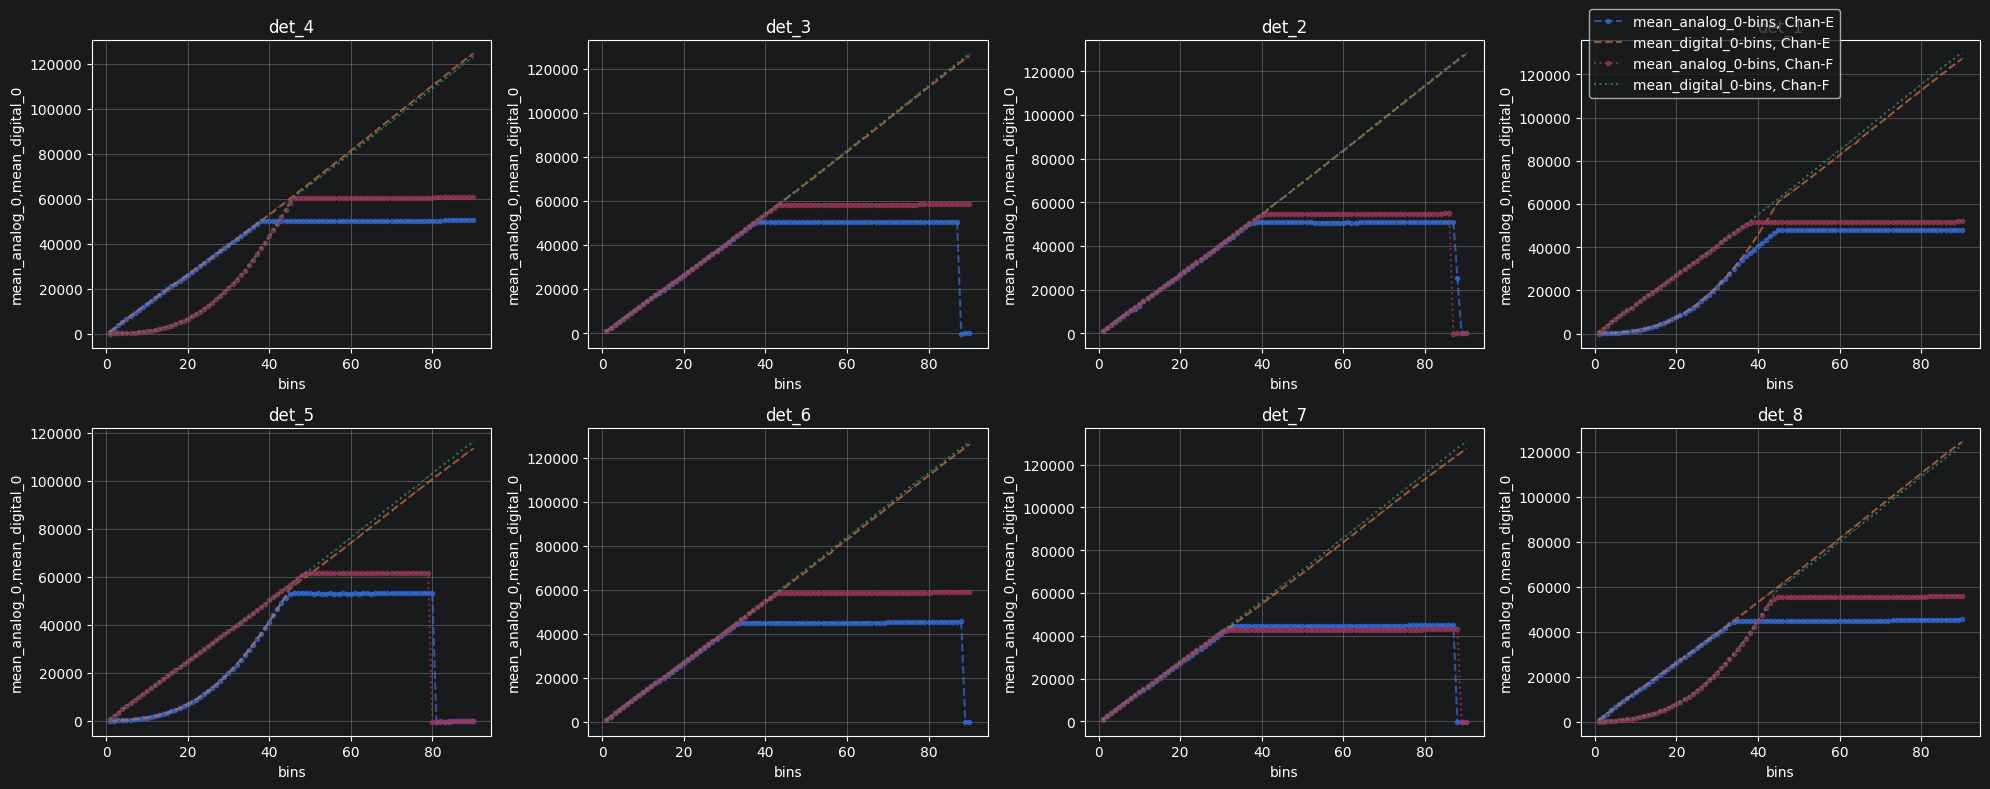

In [11]:
def _plot_panels(ax, df, y_cols, x_cols, yscale, xscale):
    from matplotlib.lines import Line2D

    axkey = {"det_1": ax[0,3], "det_2": ax[0,2], "det_3": ax[0,1], "det_4": ax[0,0],
             "det_5": ax[1,0], "det_6": ax[1,1], "det_7": ax[1,2], "det_8": ax[1,3]}
    # get matplotlib's marker list
    markers_dict = Line2D.markers
    markers_list = [m for m in markers_dict.keys() if isinstance(m, str) and m not in [' ', 'None', '', 'none']]

    for det_id, axs in axkey.items():
        axs.clear()
        for out, ls in zip(['E', 'F'], ['--','dotted']):
            dfsub = df[(df['det_id']==det_id) & (df['output']==out)].iloc[0]
            for i,col in enumerate(y_cols):
                axs.plot(list(dfsub[x_cols[i]])[:-1], list(dfsub[col])[:-1], ls=ls, label=f'{col}-{x_cols[i]}, Chan-{out}',
                         marker=markers_list[i], alpha=0.7)

        axs.set_xlabel(','.join(np.unique(x_cols)), fontsize=10)
        axs.set_ylabel(','.join(np.unique(y_cols)), fontsize=10)
        axs.set_title(det_id, fontsize=12)
        axs.grid(True)
        try:
            axs.set_xscale(xscale)
        except:
            pass
        try:
            axs.set_yscale(yscale)
        except:
            pass
    ax[0, 3].legend(ncols=1, loc='upper left', bbox_to_anchor=(0.02, 1.1), fontsize=10, borderaxespad=0)
    return ax

fig, ax = plt.subplots(2, 4, figsize=(20,8), tight_layout=True)
ax = _plot_panels(ax, df, ["mean_analog_0", "mean_digital_0"], x_cols=["bins", "bins"], yscale='linear', xscale='linear')

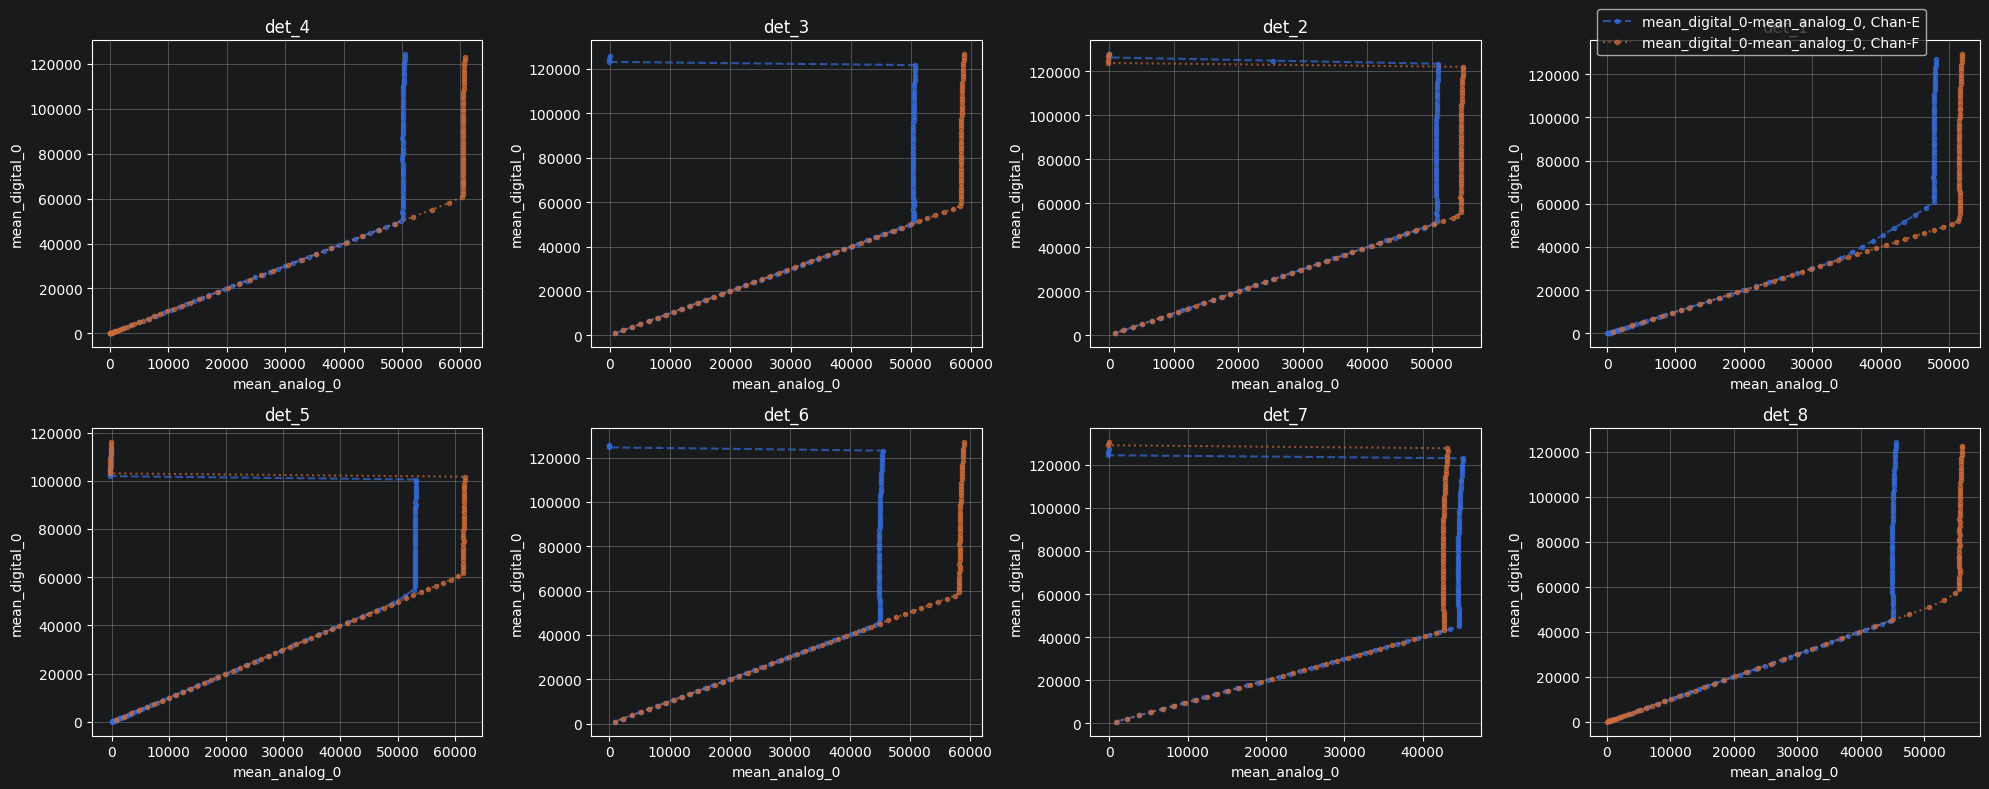

In [12]:
fig, ax = plt.subplots(2, 4, figsize=(20,8), tight_layout=True)
ax = _plot_panels(ax, df, ["mean_digital_0"], x_cols=["mean_analog_0"], yscale='linear', xscale='linear')